In [1]:
# Install TensorFlow (CPU-only version recommended for Windows)
!pip install tensorflow==2.15


  Obtaining dependency information for tensorflow==2.15 from https://files.pythonhosted.org/packages/93/21/9b035a4f823d6aee2917c75415be9a95861ff3d73a0a65e48edbf210cec1/tensorflow-2.15.0-cp311-cp311-win_amd64.whl.metadata
  Using cached tensorflow-2.15.0-cp311-cp311-win_amd64.whl.metadata (3.6 kB)
Using cached tensorflow-2.15.0-cp311-cp311-win_amd64.whl (2.1 kB)
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.20.0
    Uninstalling tensorflow-2.20.0:
      Successfully uninstalled tensorflow-2.20.0


In [3]:
import sys
print(sys.version)


3.11.5 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:26:23) [MSC v.1916 64 bit (AMD64)]


In [11]:
import tensorflow as tf
print(tf.__ver__)

AttributeError: module 'tensorflow' has no attribute '__ver__'

In [6]:
import tensorflow
print(tensorflow.__file__)


None


In [12]:
import sys
print(sys.executable)


C:\Users\user\anaconda3\python.exe


In [7]:
import sys
print(sys.path)


['C:\\Users\\user\\Untitled Folder', 'C:\\Users\\user\\anaconda3\\python311.zip', 'C:\\Users\\user\\anaconda3\\DLLs', 'C:\\Users\\user\\anaconda3\\Lib', 'C:\\Users\\user\\anaconda3', '', 'C:\\Users\\user\\anaconda3\\Lib\\site-packages', 'C:\\Users\\user\\anaconda3\\Lib\\site-packages\\win32', 'C:\\Users\\user\\anaconda3\\Lib\\site-packages\\win32\\lib', 'C:\\Users\\user\\anaconda3\\Lib\\site-packages\\Pythonwin']


In [8]:
# Remove any broken or partial installs
!pip uninstall -y tensorflow tensorflow-intel

# Reinstall TensorFlow 2.15 (compatible with Python 3.11 on Windows)
!pip install tensorflow==2.15


Found existing installation: tensorflow 2.15.0
Uninstalling tensorflow-2.15.0:
  Successfully uninstalled tensorflow-2.15.0
Found existing installation: tensorflow-intel 2.15.0
Uninstalling tensorflow-intel-2.15.0:
  Successfully uninstalled tensorflow-intel-2.15.0
  Obtaining dependency information for tensorflow==2.15 from https://files.pythonhosted.org/packages/93/21/9b035a4f823d6aee2917c75415be9a95861ff3d73a0a65e48edbf210cec1/tensorflow-2.15.0-cp311-cp311-win_amd64.whl.metadata
  Using cached tensorflow-2.15.0-cp311-cp311-win_amd64.whl.metadata (3.6 kB)
  Obtaining dependency information for tensorflow-intel==2.15.0 from https://files.pythonhosted.org/packages/4c/48/1a5a15517f18eaa4ff8d598b1c000300b20c1bb0e624539d702117a0c369/tensorflow_intel-2.15.0-cp311-cp311-win_amd64.whl.metadata
  Using cached tensorflow_intel-2.15.0-cp311-cp311-win_amd64.whl.metadata (5.1 kB)
Using cached tensorflow-2.15.0-cp311-cp311-win_amd64.whl (2.1 kB)
Using cached tensorflow_intel-2.15.0-cp311-cp311-win

In [1]:
import tensorflow as tf
print(tf.__version__)

C:\Users\user\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


2.15.0


In [10]:
import tensorflow
print(tensorflow.__file__)
print(dir(tensorflow))


None
['__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__']


In [2]:
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [4]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 [==============================] - 3s 0us/step


In [5]:
x_train, x_test = x_train/255.0,x_test/255.0

In [6]:
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

In [7]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [8]:
model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))


Epoch 1/5


1875/1875 [==============================] - 25s 12ms/step - loss: 0.1467 - accuracy: 0.9557 - val_loss: 0.0435 - val_accuracy: 0.9855
Epoch 2/5
1875/1875 [==============================] - 23s 12ms/step - loss: 0.0489 - accuracy: 0.9847 - val_loss: 0.0462 - val_accuracy: 0.9871
Epoch 3/5
1875/1875 [==============================] - 23s 12ms/step - loss: 0.0347 - accuracy: 0.9890 - val_loss: 0.0358 - val_accuracy: 0.9891
Epoch 4/5
1875/1875 [==============================] - 24s 13ms/step - loss: 0.0250 - accuracy: 0.9919 - val_loss: 0.0309 - val_accuracy: 0.9891
Epoch 5/5
1875/1875 [==============================] - 24s 13ms/step - loss: 0.0211 - accuracy: 0.9931 - val_loss: 0.0275 - val_accuracy: 0.9907


In [9]:
test_loss, test_acc = model.evaluate(x_test,y_test)
print(f"Test acc: {test_acc:.4f}")
predictions = model.predict(x_test[:5])

313/313 [==============================] - 1s 5ms/step - loss: 0.0275 - accuracy: 0.9907
Test acc: 0.9907
1/1 [==============================] - 0s 154ms/step


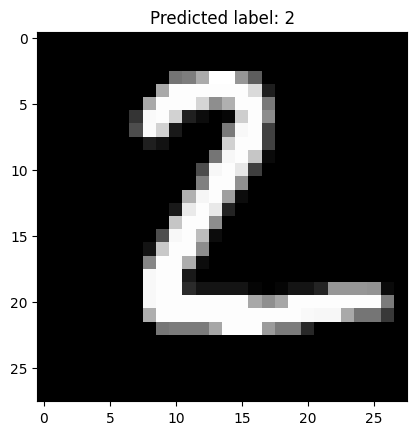

In [11]:
plt.imshow(x_test[1].reshape(28,28), cmap="gray")
plt.title(f"Predicted label: {predictions[1].argmax()}")
plt.show()          
